In [1]:
import pandas as pd
from datetime import datetime

df = pd.read_csv('../data/raw/Apple Music - Play History Daily Tracks.csv')

#change the date to the right format
time_col = 'Date Played'
df[time_col + '_parsed'] = pd.to_datetime(df[time_col].astype(str), format='%Y%m%d', errors='coerce')

#filtered
jan_start = datetime(2026, 1, 1)
jan_end = datetime(2026, 1, 31, 23, 59, 59)
filtered_df = df[(df[time_col + '_parsed'] >= jan_start) & (df[time_col + '_parsed'] <= jan_end)].dropna(subset=[time_col + '_parsed'])

if len(filtered_df) > 0:
    print(filtered_df[['Track Description', time_col + '_parsed', 'Play Duration Milliseconds']].head())
else:
    print("No data, change the data range")

filtered_df.to_csv("../data/processed/apple_playbackapple_playback_2026_jan.csv", index=False)

                   Track Description Date Played_parsed  \
47126  CUTIE STREET - かわいいだけじゃだめですか?         2026-01-01   
47127      SixTONES - JAPONICA STYLE         2026-01-02   
47128  CUTIE STREET - かわいいだけじゃだめですか?         2026-01-02   
47129    TENBLANK - Crystalline Echo         2026-01-03   
47130      SixTONES - JAPONICA STYLE         2026-01-03   

       Play Duration Milliseconds  
47126                     1481863  
47127                      439955  
47128                       72932  
47129                      693748  
47130                      335384  


In [2]:
df1=pd.read_csv('../data/processed/apple_playbackapple_playback_2026_jan.csv')
df1['Artist'] = df1['Track Description'].str.split(' - ').str[0]
top_artists = df1['Artist'].value_counts().head(10)
print(top_artists)

Artist
SixTONES         138
Mr.Children      107
FRUITS ZIPPER     29
ONE OK ROCK       28
RADWIMPS          20
Yuuri             18
CUTIE STREET      17
TENBLANK          17
ARASHI            17
CANDY TUNE        12
Name: count, dtype: int64


In [3]:
df1['Songs']=df1['Track Description'].str.split(' - ').str[1]
top_songs=df1['Songs'].value_counts().head(10)
print(top_songs)

Songs
JAPONICA STYLE                        16
Sign                                  10
かわいいだけじゃだめですか?                         8
Anmarioboetenaiya                      8
Forever Eve                            6
Crystalline Echo                       5
Glass Heart                            5
Shirushi                               5
Hatomame -Say Hello To The World.-     5
Futarigoto                             4
Name: count, dtype: int64


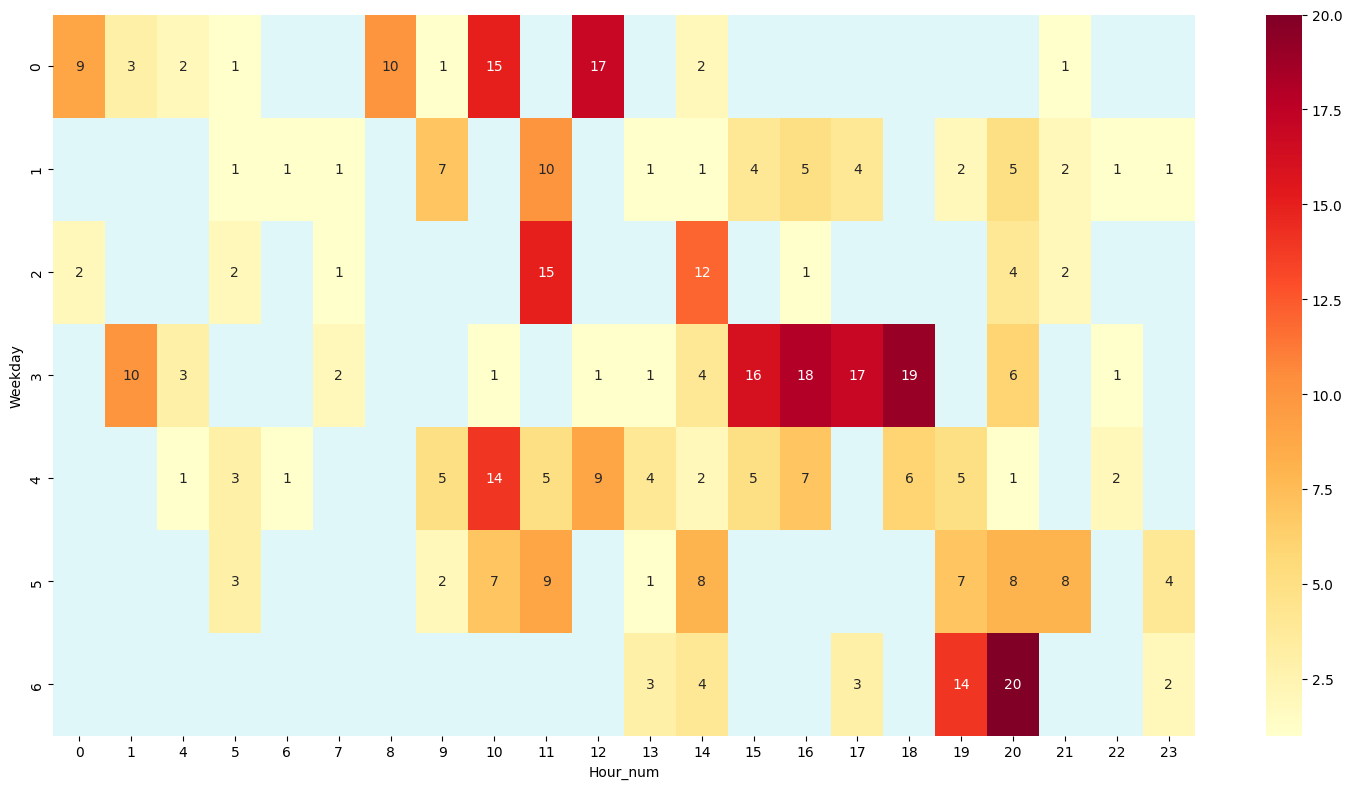

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df1['Hour_list'] = df1['Hours'].str.split(',\s*')
df_exploded = df1.explode('Hour_list').reset_index(drop=True)
df_exploded['Hour_num'] = pd.to_numeric(df_exploded['Hour_list'], errors='coerce')

df_exploded['Weekday'] = pd.to_datetime(df_exploded['Date Played_parsed']).dt.weekday

heatmap_data = df_exploded.groupby(['Weekday', 'Hour_num']).size().unstack(fill_value=0)
heatmap_data_filtered = heatmap_data[(heatmap_data >= 1) & (heatmap_data <= 20)].fillna(0).astype(int)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

mask = heatmap_data_filtered == 0

plt.figure(figsize=(15, 8))
ax = sns.heatmap(heatmap_data_filtered, annot=True, fmt='d', cmap='YlOrRd', mask=mask)

ax.set_facecolor('#E0F7FA')
plt.tight_layout()
plt.savefig('../figures/heatmap_weekday_hour.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()